In [1]:
# ============================================================
# CELL 1: INSTALL LIBRARIES
# ============================================================

!pip install -q transformers datasets torch spacy pandas numpy matplotlib seaborn scikit-learn tqdm

!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 38.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from transformers import pipeline
from datasets import load_dataset

import spacy

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ============================================================
# CELL 3: CHECK GPU
# ============================================================

if torch.cuda.is_available():

    device = 0

    print("GPU Available!")
    print("GPU:", torch.cuda.get_device_name(0))

else:

    device = -1

    print("GPU not available.")
    print("Running on CPU.")

print("Device:", device)

GPU not available.
Running on CPU.
Device: -1


In [4]:
# ============================================================
# CELL 4: LOAD SPACY
# ============================================================

nlp = spacy.load("en_core_web_sm")

print("spaCy loaded successfully!")

spaCy loaded successfully!


In [5]:
# ============================================================
# CELL 5: LOAD BIG DATASET
# ============================================================

dataset = load_dataset("fancyzhx/amazon_polarity")

print(dataset)

README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

amazon_polarity/train-00000-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  260MB            

amazon_polarity/train-00000-of-00004.par(…): downloading bytes:           |  0.00B            

amazon_polarity/train-00001-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  258MB            

amazon_polarity/train-00001-of-00004.par(…): downloading bytes:           |  0.00B            

...

amazon_polarity/test-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  117MB            

amazon_polarity/test-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})


In [6]:
# ============================================================
# CELL 6: DATASET SIZE
# ============================================================

print("Training reviews:", len(dataset["train"]))
print("Testing reviews :", len(dataset["test"]))

total_reviews = (
    len(dataset["train"]) +
    len(dataset["test"])
)

print("\nTotal reviews:", total_reviews)

Training reviews: 3600000
Testing reviews : 400000

Total reviews: 4000000


In [7]:
# ============================================================
# CELL 7: CONVERT DATASET TO PANDAS
# ============================================================

# Use a large but manageable portion for Colab processing.
# Increase this if your Colab GPU has enough resources.

TRAIN_SIZE = 50000
TEST_SIZE = 10000

train_df = dataset["train"].select(
    range(min(TRAIN_SIZE, len(dataset["train"])))
).to_pandas()

test_df = dataset["test"].select(
    range(min(TEST_SIZE, len(dataset["test"])))
).to_pandas()

df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print("Processed dataset size:", len(df))

display(df.head())

Processed dataset size: 60000


,label,title,content
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,1,Amazing!,This soundtrack is my favorite music of all ti...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [8]:
# ============================================================
# CELL 8: CREATE COMPLETE REVIEW TEXT
# ============================================================

df["title"] = df["title"].fillna("")
df["content"] = df["content"].fillna("")

df["review"] = (
    df["title"].astype(str)
    + ". "
    + df["content"].astype(str)
)

display(
    df[
        ["title", "content", "review", "label"]
    ].head()
)

,title,content,review,label
0,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...,Stuning even for the non-gamer. This sound tra...,1
1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...,The best soundtrack ever to anything.. I'm rea...,1
2,Amazing!,This soundtrack is my favorite music of all ti...,Amazing!. This soundtrack is my favorite music...,1
3,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...,Excellent Soundtrack. I truly like this soundt...,1
4,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine...","Remember, Pull Your Jaw Off The Floor After He...",1


In [9]:
# ============================================================
# CELL 9: DATA CLEANING
# ============================================================

# Remove missing reviews
df = df.dropna(
    subset=["review"]
)

# Remove empty reviews
df = df[
    df["review"].str.strip() != ""
]

# Remove duplicate reviews
df = df.drop_duplicates(
    subset=["review"]
)

# Reset index
df = df.reset_index(
    drop=True
)

print("Dataset after cleaning:", len(df))

display(df.head())

Dataset after cleaning: 60000


,label,title,content,review
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...,Stuning even for the non-gamer. This sound tra...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...,The best soundtrack ever to anything.. I'm rea...
2,1,Amazing!,This soundtrack is my favorite music of all ti...,Amazing!. This soundtrack is my favorite music...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...,Excellent Soundtrack. I truly like this soundt...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine...","Remember, Pull Your Jaw Off The Floor After He..."


In [10]:
# ============================================================
# CELL 10: DATASET STATISTICS
# ============================================================

print("Total Reviews:", len(df))

print(
    "Average Review Length:",
    round(
        df["review"].str.len().mean(),
        2
    )
)

print(
    "Maximum Review Length:",
    df["review"].str.len().max()
)

print(
    "Minimum Review Length:",
    df["review"].str.len().min()
)

Total Reviews: 60000
Average Review Length: 440.86
Maximum Review Length: 1015
Minimum Review Length: 101


In [11]:
# ============================================================
# CELL 11: ORIGINAL DATASET LABELS
# ============================================================

df["original_sentiment"] = df["label"].map({
    0: "NEGATIVE",
    1: "POSITIVE"
})

display(
    df[
        ["review", "original_sentiment"]
    ].head()
)

,review,original_sentiment
0,Stuning even for the non-gamer. This sound tra...,POSITIVE
1,The best soundtrack ever to anything.. I'm rea...,POSITIVE
2,Amazing!. This soundtrack is my favorite music...,POSITIVE
3,Excellent Soundtrack. I truly like this soundt...,POSITIVE
4,"Remember, Pull Your Jaw Off The Floor After He...",POSITIVE


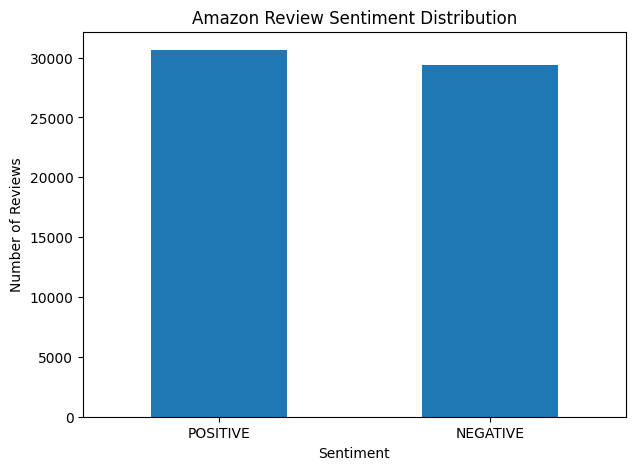

In [12]:
# ============================================================
# CELL 12: DATASET SENTIMENT DISTRIBUTION
# ============================================================

sentiment_counts = (
    df["original_sentiment"]
    .value_counts()
)

plt.figure(figsize=(7, 5))

sentiment_counts.plot(
    kind="bar"
)

plt.title(
    "Amazon Review Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.show()

In [13]:
# ============================================================
# CELL 13: LOAD BERT SENTIMENT MODEL
# ============================================================

BERT_MODEL = (
    "textattack/bert-base-uncased-SST-2"
)

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=BERT_MODEL,
    device=device
)

print("BERT sentiment model loaded!")

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BERT sentiment model loaded!


In [14]:
# ============================================================
# CELL 14: TEST BERT
# ============================================================

sample_review = (
    "This product is amazing and "
    "I absolutely love the quality."
)

result = sentiment_pipeline(
    sample_review
)[0]

print("Review:", sample_review)
print("Sentiment:", result["label"])
print(
    "Confidence:",
    f"{result['score']:.2%}"
)

Review: This product is amazing and I absolutely love the quality.
Sentiment: LABEL_1
Confidence: 99.96%


In [15]:
# ============================================================
# CELL 15: BERT BATCH SENTIMENT ANALYSIS
# ============================================================

BERT_SAMPLE_SIZE = 10000

bert_df = df.head(
    min(BERT_SAMPLE_SIZE, len(df))
).copy()

texts = bert_df["review"].tolist()

batch_size = 32

bert_results = []

for i in tqdm(
    range(
        0,
        len(texts),
        batch_size
    ),
    desc="BERT Sentiment Analysis"
):

    batch = texts[
        i:i + batch_size
    ]

    results = sentiment_pipeline(
        batch,
        truncation=True,
        max_length=512
    )

    bert_results.extend(results)

BERT Sentiment Analysis:   0%|          | 0/313 [00:00<?, ?it/s]

In [16]:
# ============================================================
# CELL 16: STORE BERT RESULTS
# ============================================================

bert_df["bert_sentiment"] = [
    result["label"]
    for result in bert_results
]

bert_df["bert_confidence"] = [
    result["score"]
    for result in bert_results
]

bert_df["bert_confidence_percent"] = (
    bert_df["bert_confidence"] * 100
).round(2)

display(
    bert_df[
        [
            "review",
            "bert_sentiment",
            "bert_confidence_percent"
        ]
    ].head(10)
)

,review,bert_sentiment,bert_confidence_percent
0,Stuning even for the non-gamer. This sound tra...,LABEL_1,99.96
1,The best soundtrack ever to anything.. I'm rea...,LABEL_1,99.90
2,Amazing!. This soundtrack is my favorite music...,LABEL_1,99.96
3,Excellent Soundtrack. I truly like this soundt...,LABEL_1,99.95
4,"Remember, Pull Your Jaw Off The Floor After He...",LABEL_1,99.94
5,an absolute masterpiece. I am quite sure any o...,LABEL_1,99.96
6,"Buyer beware. This is a self-published book, a...",LABEL_0,99.83
7,Glorious story. I loved Whisper of the wicked ...,LABEL_1,99.89
8,A FIVE STAR BOOK. I just finished reading Whis...,LABEL_1,99.96
9,Whispers of the Wicked Saints. This was a easy...,LABEL_1,99.95


In [17]:
# ============================================================
# CELL 17: COMPARE ORIGINAL LABEL AND BERT
# ============================================================

comparison = pd.crosstab(
    bert_df["original_sentiment"],
    bert_df["bert_sentiment"]
)

display(comparison)

bert_sentiment,LABEL_0,LABEL_1
original_sentiment,,
NEGATIVE,4741,356
POSITIVE,553,4350


In [18]:
# ============================================================
# CELL 18: CANDIDATE ASPECT EXTRACTION
# ============================================================

def extract_candidate_aspects(text):

    doc = nlp(text)

    aspects = []

    for token in doc:

        if token.pos_ in [
            "NOUN",
            "PROPN"
        ]:

            word = token.text.lower()

            if (
                len(word) > 2
                and word not in aspects
            ):

                aspects.append(word)

    return aspects

In [19]:
# ============================================================
# CELL 19: TEST ASPECT EXTRACTION
# ============================================================

test_review = """
The camera takes amazing photos,
but the battery drains quickly
and the screen is too dim.
"""

candidate_aspects = (
    extract_candidate_aspects(
        test_review
    )
)

print("Review:")
print(test_review)

print("\nCandidate Aspects:")
print(candidate_aspects)

Review:

The camera takes amazing photos,
but the battery drains quickly
and the screen is too dim.


Candidate Aspects:
['camera', 'photos', 'battery', 'screen']


In [20]:
# ============================================================
# CELL 20: ASPECT EXTRACTION ON LARGE DATASET
# ============================================================

ASPECT_SAMPLE_SIZE = 5000

aspect_df = df.head(
    min(
        ASPECT_SAMPLE_SIZE,
        len(df)
    )
).copy()

texts = aspect_df[
    "review"
].tolist()

candidate_aspect_lists = []

for doc in tqdm(
    nlp.pipe(
        texts,
        batch_size=64
    ),
    total=len(texts),
    desc="Extracting Candidate Aspects"
):

    aspects = []

    for token in doc:

        if token.pos_ in [
            "NOUN",
            "PROPN"
        ]:

            word = token.text.lower()

            if (
                len(word) > 2
                and word not in aspects
            ):

                aspects.append(word)

    candidate_aspect_lists.append(
        aspects
    )


aspect_df[
    "candidate_aspects"
] = candidate_aspect_lists

display(
    aspect_df[
        [
            "review",
            "candidate_aspects"
        ]
    ].head(10)
)

Extracting Candidate Aspects:   0%|          | 0/5000 [00:00<?, ?it/s]

,review,candidate_aspects
0,Stuning even for the non-gamer. This sound tra...,"[gamer, track, senery, mind, people, vid, game..."
1,The best soundtrack ever to anything.. I'm rea...,"[soundtrack, lot, reviews, game, review, bit, ..."
2,Amazing!. This soundtrack is my favorite music...,"[soundtrack, music, time, sadness, prisoners, ..."
3,Excellent Soundtrack. I truly like this soundt...,"[excellent, soundtrack, video, game, music, di..."
4,"Remember, Pull Your Jaw Off The Floor After He...","[jaw, floor, game, music, song, story, songs, ..."
5,an absolute masterpiece. I am quite sure any o...,"[masterpiece, time, game, tracks, mitsuda, mus..."
6,"Buyer beware. This is a self-published book, a...","[buyer, self, book, paragraphs, star, reviews,..."
7,Glorious story. I loved Whisper of the wicked ...,"[story, whisper, saints, changes, book, normal..."
8,A FIVE STAR BOOK. I just finished reading Whis...,"[star, book, whisper, saints, love, caracters,..."
9,Whispers of the Wicked Saints. This was a easy...,"[whispers, wicked, saints, book, follow, lot]"


In [21]:
# ============================================================
# CELL 21: MOST COMMON ASPECTS
# ============================================================

from collections import Counter

aspect_counter = Counter()

for aspects in aspect_df[
    "candidate_aspects"
]:

    aspect_counter.update(
        aspects
    )

top_aspects = (
    aspect_counter
    .most_common(30)
)

top_aspects_df = pd.DataFrame(
    top_aspects,
    columns=[
        "aspect",
        "frequency"
    ]
)

display(top_aspects_df)

,aspect,frequency
0,book,1410
1,time,826
2,movie,504
3,one,476
4,product,468
5,money,428
6,story,406
7,way,386
8,people,348
9,music,323


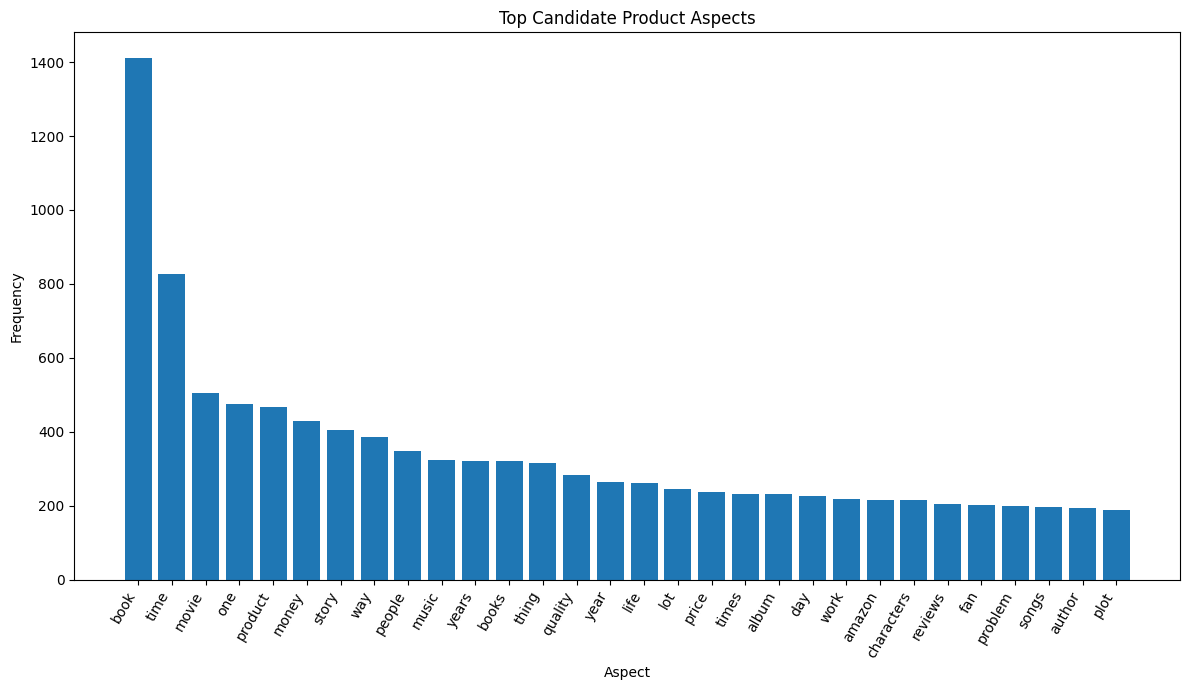

In [22]:
# ============================================================
# CELL 22: TOP ASPECT VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 7))

plt.bar(
    top_aspects_df["aspect"],
    top_aspects_df["frequency"]
)

plt.title(
    "Top Candidate Product Aspects"
)

plt.xlabel("Aspect")
plt.ylabel("Frequency")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()

plt.show()

In [23]:
# ============================================================
# CELL 23: LOAD ABSA MODEL
# ============================================================

ABSA_MODEL = (
    "yangheng/deberta-v3-base-absa-v1.1"
)

absa_pipeline = pipeline(
    "text-classification",
    model=ABSA_MODEL,
    device=device
)

print("ABSA model loaded!")

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

ABSA model loaded!


In [24]:
# ============================================================
# CELL 24: ABSA FUNCTION
# ============================================================

def analyze_aspect(
    review,
    aspect
):

    result = absa_pipeline(
        review,
        text_pair=aspect,
        truncation=True,
        max_length=512
    )[0]

    return {
        "aspect": aspect,
        "sentiment": result["label"],
        "confidence": result["score"]
    }

In [25]:
# ============================================================
# CELL 25: CODING CHALLENGE
# ============================================================

challenge_review = """
The camera takes amazing photos,
but the battery drains quickly
and the screen is too dim.
"""

challenge_aspects = [
    "camera",
    "photos",
    "battery",
    "screen"
]

challenge_results = []

for aspect in challenge_aspects:

    result = analyze_aspect(
        challenge_review,
        aspect
    )

    challenge_results.append(
        result
    )

challenge_df = pd.DataFrame(
    challenge_results
)

challenge_df[
    "confidence_percent"
] = (
    challenge_df["confidence"] * 100
).round(2)

display(
    challenge_df[
        [
            "aspect",
            "sentiment",
            "confidence_percent"
        ]
    ]
)

,aspect,sentiment,confidence_percent
0,camera,Positive,95.79
1,photos,Positive,99.62
2,battery,Negative,99.56
3,screen,Negative,99.58


In [26]:
# ============================================================
# CELL 26: ABSA ON LARGE REVIEW SAMPLE
# ============================================================

ABSA_REVIEW_LIMIT = 500
TOP_ASPECT_LIMIT = 10

absa_input_df = aspect_df.head(
    min(
        ABSA_REVIEW_LIMIT,
        len(aspect_df)
    )
).copy()

selected_aspects = (
    top_aspects_df
    .head(TOP_ASPECT_LIMIT)
    ["aspect"]
    .tolist()
)

print(
    "Reviews selected:",
    len(absa_input_df)
)

print(
    "Aspects selected:",
    selected_aspects
)

Reviews selected: 500
Aspects selected: ['book', 'time', 'movie', 'one', 'product', 'money', 'story', 'way', 'people', 'music']


In [27]:
# ============================================================
# CELL 27: CREATE REVIEW-ASPECT PAIRS
# ============================================================

pairs = []

for _, row in absa_input_df.iterrows():

    review = row["review"]

    candidate_aspects = (
        row["candidate_aspects"]
    )

    for aspect in candidate_aspects:

        if aspect in selected_aspects:

            pairs.append(
                {
                    "review": review,
                    "aspect": aspect
                }
            )

pairs_df = pd.DataFrame(
    pairs
)

print(
    "Review-aspect pairs:",
    len(pairs_df)
)

display(
    pairs_df.head(20)
)

Review-aspect pairs: 595


,review,aspect
0,Stuning even for the non-gamer. This sound tra...,people
1,Stuning even for the non-gamer. This sound tra...,music
2,The best soundtrack ever to anything.. I'm rea...,music
3,The best soundtrack ever to anything.. I'm rea...,money
4,Amazing!. This soundtrack is my favorite music...,music
5,Amazing!. This soundtrack is my favorite music...,time
6,Excellent Soundtrack. I truly like this soundt...,music
7,Excellent Soundtrack. I truly like this soundt...,time
8,"Remember, Pull Your Jaw Off The Floor After He...",music
9,"Remember, Pull Your Jaw Off The Floor After He...",story


In [28]:
# ============================================================
# CELL 28: RUN ABSA
# ============================================================

absa_results = []

for _, row in tqdm(
    pairs_df.iterrows(),
    total=len(pairs_df),
    desc="Running ABSA"
):

    result = analyze_aspect(
        row["review"],
        row["aspect"]
    )

    absa_results.append(
        {
            "review": row["review"],
            "aspect": row["aspect"],
            "sentiment": result["sentiment"],
            "confidence": result["confidence"]
        }
    )

absa_results_df = pd.DataFrame(
    absa_results
)

absa_results_df[
    "confidence_percent"
] = (
    absa_results_df["confidence"] * 100
).round(2)

display(
    absa_results_df.head(20)
)

Running ABSA:   0%|          | 0/595 [00:00<?, ?it/s]

,review,aspect,sentiment,confidence,confidence_percent
0,Stuning even for the non-gamer. This sound tra...,people,Positive,0.983445,98.34
1,Stuning even for the non-gamer. This sound tra...,music,Positive,0.991382,99.14
2,The best soundtrack ever to anything.. I'm rea...,music,Positive,0.987558,98.76
3,The best soundtrack ever to anything.. I'm rea...,money,Positive,0.784833,78.48
4,Amazing!. This soundtrack is my favorite music...,music,Positive,0.989167,98.92
5,Amazing!. This soundtrack is my favorite music...,time,Positive,0.910815,91.08
6,Excellent Soundtrack. I truly like this soundt...,music,Positive,0.990719,99.07
7,Excellent Soundtrack. I truly like this soundt...,time,Positive,0.976085,97.61
8,"Remember, Pull Your Jaw Off The Floor After He...",music,Positive,0.977365,97.74
9,"Remember, Pull Your Jaw Off The Floor After He...",story,Positive,0.811372,81.14


In [29]:
# ============================================================
# CELL 29: POSITIVE / NEGATIVE ASPECTS
# ============================================================

positive_aspects = (
    absa_results_df[
        absa_results_df[
            "sentiment"
        ].str.lower() == "positive"
    ]
)

negative_aspects = (
    absa_results_df[
        absa_results_df[
            "sentiment"
        ].str.lower() == "negative"
    ]
)

print("POSITIVE ASPECTS")
print("================")

display(
    positive_aspects[
        [
            "aspect",
            "confidence_percent"
        ]
    ].head(20)
)

print("\nNEGATIVE ASPECTS")
print("================")

display(
    negative_aspects[
        [
            "aspect",
            "confidence_percent"
        ]
    ].head(20)
)

POSITIVE ASPECTS


,aspect,confidence_percent
0,people,98.34
1,music,99.14
2,music,98.76
3,money,78.48
4,music,98.92
5,time,91.08
6,music,99.07
7,time,97.61
8,music,97.74
9,story,81.14



NEGATIVE ASPECTS


,aspect,confidence_percent
13,book,97.87
14,one,95.60
20,time,99.56
21,book,99.20
24,one,88.79
25,book,97.00
26,money,96.47
27,book,98.70
31,people,98.56
32,time,90.14


In [30]:
# ============================================================
# CELL 30: ASPECT SENTIMENT SUMMARY
# ============================================================

aspect_summary = (
    absa_results_df
    .groupby(
        ["aspect", "sentiment"]
    )
    .size()
    .reset_index(
        name="count"
    )
)

display(
    aspect_summary
)

,aspect,sentiment,count
0,book,Negative,72
1,book,Neutral,7
2,book,Positive,94
3,money,Negative,31
4,money,Neutral,3
5,money,Positive,8
6,movie,Negative,25
7,movie,Neutral,1
8,movie,Positive,15
9,music,Negative,10


In [31]:
# ============================================================
# CELL 31: ASPECT SENTIMENT PIVOT
# ============================================================

pivot = pd.pivot_table(
    absa_results_df,
    index="aspect",
    columns="sentiment",
    values="confidence",
    aggfunc="count",
    fill_value=0
)

display(pivot)

sentiment,Negative,Neutral,Positive
aspect,,,
book,72,7,94
money,31,3,8
movie,25,1,15
music,10,3,18
one,31,0,24
people,30,3,16
product,16,1,13
story,19,3,30
time,51,5,37


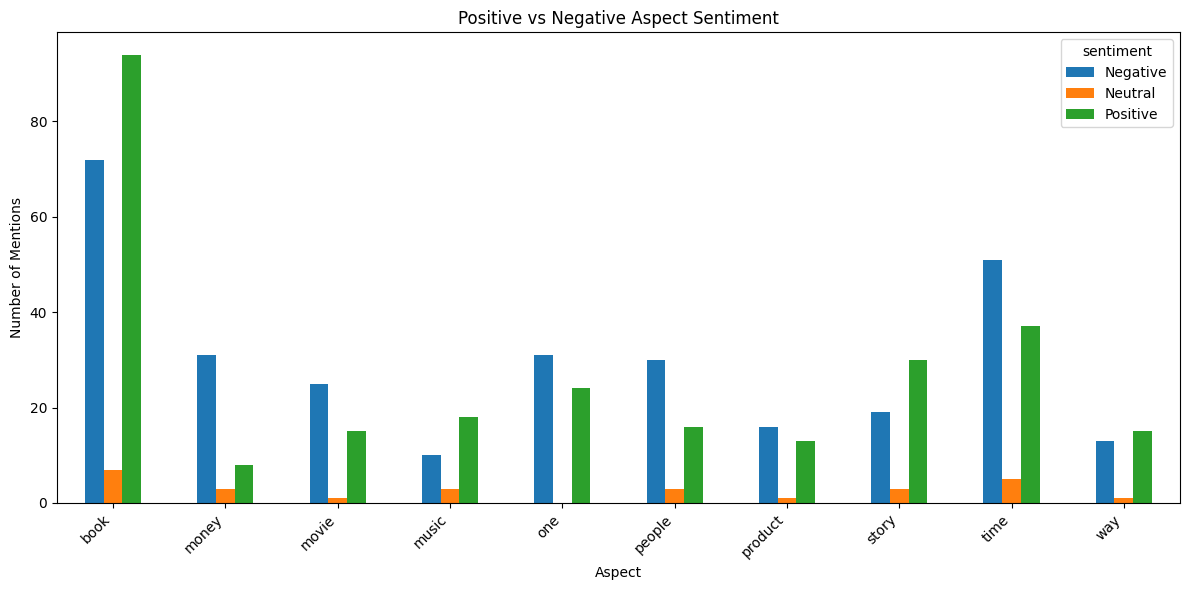

In [32]:
# ============================================================
# CELL 32: ASPECT SENTIMENT CHART
# ============================================================

pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Positive vs Negative Aspect Sentiment"
)

plt.xlabel("Aspect")

plt.ylabel(
    "Number of Mentions"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [33]:
# ============================================================
# CELL 33: AVERAGE ASPECT CONFIDENCE
# ============================================================

confidence_summary = (
    absa_results_df
    .groupby("aspect")
    ["confidence"]
    .mean()
    .sort_values(
        ascending=False
    )
)

confidence_summary = (
    confidence_summary * 100
)

print(
    "Average confidence by aspect:"
)

display(
    confidence_summary
    .round(2)
    .to_frame(
        "Average Confidence (%)"
    )
)

Average confidence by aspect:


,Average Confidence (%)
aspect,
book,92.34
movie,90.50
music,90.02
story,89.44
money,88.75
time,88.32
one,87.48
people,87.42
product,87.37


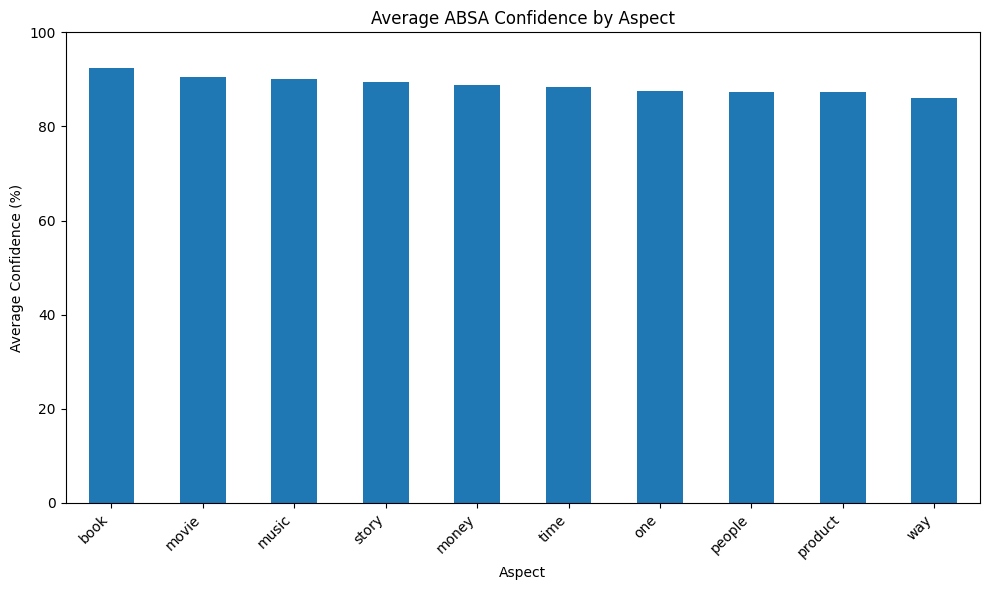

In [34]:
# ============================================================
# CELL 34: CONFIDENCE CHART
# ============================================================

plt.figure(figsize=(10, 6))

confidence_summary.plot(
    kind="bar"
)

plt.title(
    "Average ABSA Confidence by Aspect"
)

plt.xlabel("Aspect")

plt.ylabel(
    "Average Confidence (%)"
)

plt.ylim(
    0,
    100
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [35]:
# ============================================================
# CELL 35: PRODUCT REVIEW INTELLIGENCE DASHBOARD
# ============================================================

total_reviews = len(df)

processed_reviews = len(
    bert_df
)

total_aspect_pairs = len(
    absa_results_df
)

positive_count = len(
    positive_aspects
)

negative_count = len(
    negative_aspects
)

print("=" * 65)

print(
    "        PRODUCT REVIEW INTELLIGENCE SYSTEM"
)

print("=" * 65)

print(
    f"\nTotal Dataset Reviews      : {total_reviews:,}"
)

print(
    f"Reviews analyzed by BERT  : {processed_reviews:,}"
)

print(
    f"Aspect-review pairs       : {total_aspect_pairs:,}"
)

print(
    f"Positive Aspect Opinions  : {positive_count:,}"
)

print(
    f"Negative Aspect Opinions  : {negative_count:,}"
)

if total_aspect_pairs > 0:

    positive_rate = (
        positive_count /
        total_aspect_pairs
    ) * 100

    negative_rate = (
        negative_count /
        total_aspect_pairs
    ) * 100

    print(
        f"\nPositive Aspect Rate      : "
        f"{positive_rate:.2f}%"
    )

    print(
        f"Negative Aspect Rate      : "
        f"{negative_rate:.2f}%"
    )

print("\n" + "=" * 65)

        PRODUCT REVIEW INTELLIGENCE SYSTEM

Total Dataset Reviews      : 60,000
Reviews analyzed by BERT  : 10,000
Aspect-review pairs       : 595
Positive Aspect Opinions  : 270
Negative Aspect Opinions  : 298

Positive Aspect Rate      : 45.38%
Negative Aspect Rate      : 50.08%



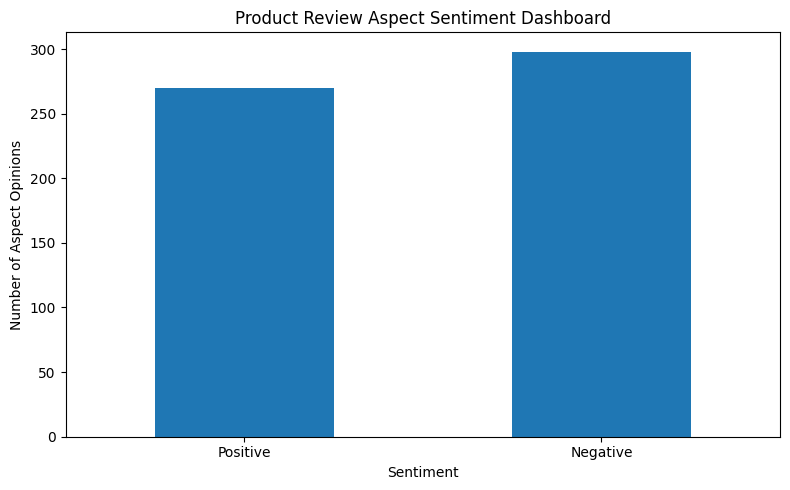

In [36]:
# ============================================================
# CELL 36: FINAL DASHBOARD CHART
# ============================================================

dashboard_data = pd.Series({
    "Positive": positive_count,
    "Negative": negative_count
})

plt.figure(figsize=(8, 5))

dashboard_data.plot(
    kind="bar"
)

plt.title(
    "Product Review Aspect Sentiment Dashboard"
)

plt.xlabel("Sentiment")

plt.ylabel(
    "Number of Aspect Opinions"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [37]:
# ============================================================
# CELL 37: INTERACTIVE REVIEW
# ============================================================

user_review = input(
    "Enter your customer review:\n"
)

user_aspects = input(
    "\nEnter aspects separated by commas:\n"
)

aspects = [
    aspect.strip()
    for aspect in user_aspects.split(",")
    if aspect.strip()
]

interactive_results = []

for aspect in aspects:

    result = analyze_aspect(
        user_review,
        aspect
    )

    interactive_results.append(
        result
    )

interactive_df = pd.DataFrame(
    interactive_results
)

interactive_df[
    "confidence_percent"
] = (
    interactive_df["confidence"] * 100
).round(2)

display(
    interactive_df[
        [
            "aspect",
            "sentiment",
            "confidence_percent"
        ]
    ]
)

Enter your customer review:
The shirt looks great and the fabric feels soft

Enter aspects separated by commas:
shirt, fabric


,aspect,sentiment,confidence_percent
0,shirt,Positive,99.74
1,fabric,Positive,99.85


In [38]:
# ============================================================
# CELL 38: MINI CLASSROOM ASSESSMENT
# ============================================================

questions = {

"What is sentiment analysis?":
"""Sentiment analysis identifies whether a text expresses
positive, negative, or neutral sentiment.""",

"What is BERT?":
"""BERT is a pretrained transformer-based language model
that understands the context of words.""",

"What does a tokenizer do?":
"""A tokenizer converts text into tokens and numerical
IDs that a language model can process.""",

"What is a pretrained model?":
"""A pretrained model is already trained on a large amount
of data and can be adapted for a specific task.""",

"What is confidence?":
"""Confidence indicates how strongly the model supports
its prediction.""",

"Why can a mixed review be difficult for binary sentiment classification?":
"""A mixed review can contain positive and negative opinions
about different aspects, while binary classification gives
one overall prediction.""",

"What is ABSA?":
"""ABSA means Aspect-Based Sentiment Analysis. It determines
sentiment toward a specific aspect.""",

"Why do we provide an aspect to an ABSA model?":
"""The aspect tells the model which specific part of the
review should be analyzed.""",

"What is the difference between document-level and aspect-level sentiment?":
"""Document-level sentiment gives one overall sentiment for
the complete review, while aspect-level sentiment gives
sentiment for individual aspects.""",

"Why is simple noun extraction not a complete aspect-extraction solution?":
"""Not every noun is an aspect. Some aspects can be
multi-word or context-dependent."""
}

for question, answer in questions.items():

    print("\nQUESTION:")
    print(question)

    print("\nANSWER:")
    print(answer)

    print("-" * 60)


QUESTION:
What is sentiment analysis?

ANSWER:
Sentiment analysis identifies whether a text expresses
positive, negative, or neutral sentiment.
------------------------------------------------------------

QUESTION:
What is BERT?

ANSWER:
BERT is a pretrained transformer-based language model
that understands the context of words.
------------------------------------------------------------

QUESTION:
What does a tokenizer do?

ANSWER:
A tokenizer converts text into tokens and numerical
IDs that a language model can process.
------------------------------------------------------------

QUESTION:
What is a pretrained model?

ANSWER:
A pretrained model is already trained on a large amount
of data and can be adapted for a specific task.
------------------------------------------------------------

QUESTION:
What is confidence?

ANSWER:
Confidence indicates how strongly the model supports
its prediction.
------------------------------------------------------------

QUESTION:
Why can a mixe

In [39]:
# ============================================================
# CELL 39: FINAL SUMMARY
# ============================================================

print("""
============================================================
          PRODUCT REVIEW INTELLIGENCE SYSTEM
============================================================

BIG DATASET
    ↓
Amazon Product Reviews
    ↓
Data Cleaning
    ↓
Large Number of Customer Reviews
    ↓
BERT
    ↓
Overall Sentiment
    ↓
Candidate Aspect Extraction
    ↓
ABSA
    ↓
Aspect-Level Sentiment
    ↓
Confidence Score
    ↓
Positive / Negative Aspect Analysis
    ↓
Visualization
    ↓
Dashboard


MAIN DIFFERENCE
---------------

Normal Sentiment Analysis:

Review → Overall Sentiment


ABSA:

Review + Aspect → Aspect Sentiment


Example:

"I love the camera but hate the battery."

camera  → Positive
battery → Negative


PROJECT OBJECTIVES
------------------

✓ Accept customer reviews
✓ Use a large review dataset
✓ Extract candidate aspects
✓ Predict aspect-level sentiment
✓ Calculate confidence
✓ Visualize positive aspects
✓ Visualize negative aspects
✓ Generate a dashboard


IMPORTANT CLASSROOM NOTE
------------------------

The noun/proper-noun extraction method used here is a
simple teaching approach.

It is NOT a complete production-level aspect extraction
system.

============================================================
                    PROJECT COMPLETE
============================================================
""")


          PRODUCT REVIEW INTELLIGENCE SYSTEM

BIG DATASET
    ↓
Amazon Product Reviews
    ↓
Data Cleaning
    ↓
Large Number of Customer Reviews
    ↓
BERT
    ↓
Overall Sentiment
    ↓
Candidate Aspect Extraction
    ↓
ABSA
    ↓
Aspect-Level Sentiment
    ↓
Confidence Score
    ↓
Positive / Negative Aspect Analysis
    ↓
Visualization
    ↓
Dashboard


MAIN DIFFERENCE
---------------

Normal Sentiment Analysis:

Review → Overall Sentiment


ABSA:

Review + Aspect → Aspect Sentiment


Example:

"I love the camera but hate the battery."

camera  → Positive
battery → Negative


PROJECT OBJECTIVES
------------------

✓ Accept customer reviews
✓ Use a large review dataset
✓ Extract candidate aspects
✓ Predict aspect-level sentiment
✓ Calculate confidence
✓ Visualize positive aspects
✓ Visualize negative aspects
✓ Generate a dashboard


IMPORTANT CLASSROOM NOTE
------------------------

The noun/proper-noun extraction method used here is a
simple teaching approach.

It is NOT a complete 